In [9]:
%matplotlib inline
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lmfit
from scipy.ndimage import gaussian_filter1d

# Apply PowerPoint presentation-friendly styling
# Matching formatting colors (Maroon, Black, White) from the slide
plt.style.use("default")
plt.rcParams.update({
    "lines.dash_capstyle": "round",
    "lines.solid_capstyle": "round",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Garamond", "serif"],
    "font.size": 16, # Larger text for presentation readability
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "legend.fontsize": 14,
})

In [10]:
# Setup path and load CSV data
data_dir = pathlib.Path.home() / ".qd_spec" / "run_20260325_163942"

blank_raw_df = pd.read_csv(data_dir / "blank_blank.csv")
blank_dark_df = pd.read_csv(data_dir / "blank_blank_dark.csv")
sample_raw_df = pd.read_csv(data_dir / "32126 bottom_a3b7ea92_sample.csv")
sample_dark_df = pd.read_csv(data_dir / "32126 bottom_a3b7ea92_dark.csv")

# Extract arrays
wavelengths = blank_raw_df["Wavelength"].values
blank_raw = blank_raw_df["intensity"].values
blank_dark = blank_dark_df["intensity"].values
sample_raw = sample_raw_df["intensity"].values
sample_dark = sample_dark_df["intensity"].values

# Preprocess arrays directly 
blank_corrected = blank_raw - blank_dark
sample_corrected = sample_raw - sample_dark
sample_processed = sample_corrected - blank_corrected

In [11]:
# Define Model fitting functions directly
def double_gauss(x, a1, x01, dx1, a2, x02, dx2, yOff):
    term1 = a1 * np.exp(-((x - x01) ** 2) / (2 * dx1**2))
    term2 = a2 * np.exp(-((x - x02) ** 2) / (2 * dx2**2))
    return term1 + term2 + yOff

def single_gauss(x, a, x0, dx, yOff):
    return a * np.exp(-((x - x0) ** 2) / (2 * dx**2)) + yOff

# Configure the lmfit model and parameters
model = lmfit.Model(double_gauss)
params = model.make_params(
    a1=500, x01=500, dx1=20, 
    a2=500, x02=600, dx2=20, 
    yOff=10
)

# Apply bounds based on our knowledge of QD spectra
params["a1"].set(min=0)
params["a2"].set(min=0)
params["dx1"].set(min=5)
params["dx2"].set(min=5)

# Heuristic: Smooth data and find rough peak to center parameters
peak_est = wavelengths[gaussian_filter1d(sample_processed, sigma=5).argmax()]
params["x01"].set(value=peak_est - 20)
params["x02"].set(value=peak_est + 20)

# Perform fit
result = model.fit(sample_processed, params, x=wavelengths)
print(result.fit_report())

[[Model]]
    Model(double_gauss)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 122
    # data points      = 2048
    # variables        = 7
    chi-square         = 527754.715
    reduced chi-square = 258.576538
    Akaike info crit   = 11384.0207
    Bayesian info crit = 11423.3930
    R-squared          = 0.98398263
[[Variables]]
    a1:    150.207680 +/- 3.95647533 (2.63%) (init = 500)
    x01:   886.740418 +/- 3.47957714 (0.39%) (init = 934.3576)
    dx1:   83.2970741 +/- 1.60290210 (1.92%) (init = 20)
    a2:    328.480061 +/- 6.98626360 (2.13%) (init = 500)
    x02:   963.564708 +/- 0.29752084 (0.03%) (init = 974.3576)
    dx2:   39.7186655 +/- 0.56171977 (1.41%) (init = 20)
    yOff:  0.59410995 +/- 0.51756310 (87.12%) (init = 10)
[[Correlations]] (unreported correlations are < 0.100)
    C(x01, a2)   = -0.9727
    C(x01, dx2)  = -0.9051
    C(a1, a2)    = -0.9032
    C(a1, dx2)   = -0.9013
    C(a1, x01)   = +0.9006
    C(a2, dx2)   = +0.8611
   

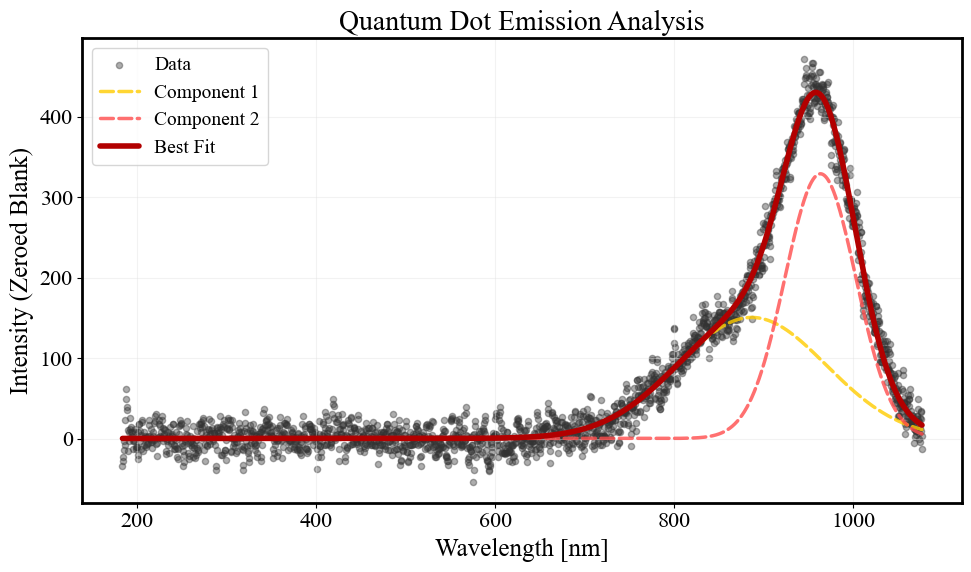

In [ ]:
# Standalone matplotlib plotting script - Simplified for Presentation

# Matching colors from presentation theme:
# Data: black or dark grey to stay understated
data_color = "#333333" 
# Fit Line: deep maroon/red from presentation border
fit_color = "#B20000" 
# Components: yellow and secondary red
colors = ["#FFCC00", "#FF4C4C"] 

fig, ax = plt.subplots(figsize=(10, 6))

# Processed (Zeroed) Sample showing components vs data vs fit
ax.set_title("Quantum Dot Emission Analysis")
ax.scatter(wavelengths, sample_processed, s=20, alpha=0.4, color=data_color, label="Data")

# Evaluate Sub-components
for i, comp_color in zip([1, 2], colors):
    comp = single_gauss(
        wavelengths, 
        a=result.params[f"a{i}"].value, 
        x0=result.params[f"x0{i}"].value, 
        dx=result.params[f"dx{i}"].value, 
        yOff=result.params["yOff"].value
    )
    ax.plot(wavelengths, comp, "--", color=comp_color, lw=2.5, alpha=0.8, label=f"Component {i}")

# Evaluate best fit over total line
ax.plot(wavelengths, result.best_fit, color=fit_color, lw=4, alpha=1.0, label="Best Fit")

ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Intensity (Zeroed Blank)")
ax.legend()
ax.grid(True, alpha=0.4, color="#e0e0e0")

# Add a nice solid black border around the entire plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(2.0)

plt.tight_layout()
plt.show()